In [29]:
import pandas as pd 
df=pd.read_csv("/Users/anishjain/Downloads/adult.csv")
df.head()

,Age,Workclass,Final Weight,Education,EducationNum,Marital Status,Occupation,Relationship,Race,Gender,Capital Gain,capital loss,Hours per Week,Native Country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [30]:
df.tail()

,Age,Workclass,Final Weight,Education,EducationNum,Marital Status,Occupation,Relationship,Race,Gender,Capital Gain,capital loss,Hours per Week,Native Country,Income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [31]:
df.shape

(32561, 15)

In [32]:
df.isnull().sum()

Age               0
Workclass         0
Final Weight      0
Education         0
EducationNum      0
Marital Status    0
Occupation        0
Relationship      0
Race              0
Gender            0
Capital Gain      0
capital loss      0
Hours per Week    0
Native Country    0
Income            0
dtype: int64

In [33]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df.replace(' ?', np.nan, inplace=True)
df.dropna(inplace=True)

# Encode categorical variables
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
df.head()


,Age,Workclass,Final Weight,Education,EducationNum,Marital Status,Occupation,Relationship,Race,Gender,Capital Gain,capital loss,Hours per Week,Native Country,Income
0,39,5,77516,9,13,4,0,1,4,1,2174,0,40,38,0
1,50,4,83311,9,13,2,3,0,4,1,0,0,13,38,0
2,38,2,215646,11,9,0,5,1,4,1,0,0,40,38,0
3,53,2,234721,1,7,2,5,0,2,1,0,0,40,38,0
4,28,2,338409,9,13,2,9,5,2,0,0,0,40,4,0


In [73]:
df.tail()

,Age,Workclass,Final Weight,Education,EducationNum,Marital Status,Occupation,Relationship,Race,Gender,Capital Gain,capital loss,Hours per Week,Native Country,Income
32556,27,2,257302,7,12,2,12,5,4,0,0,0,38,38,0
32557,40,2,154374,11,9,2,6,0,4,1,0,0,40,38,1
32558,58,2,151910,11,9,6,0,4,4,0,0,0,40,38,0
32559,22,2,201490,11,9,4,0,3,4,1,0,0,20,38,0
32560,52,3,287927,11,9,2,3,5,4,0,15024,0,40,38,1


In [34]:
df['Income'].unique()

array([0, 1])

In [64]:
X = df.drop('Income', axis=1)
y = df['Income']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [10,15,20],
    'class_weight': ['balanced', None]
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
best_model = search.best_estimator_

best_model

RandomForestClassifier(class_weight='balanced', min_samples_split=10,
                       n_estimators=200, random_state=42)

In [65]:
# Train Random Forest classifier
rf_model = RandomForestClassifier(class_weight='balanced', min_samples_split=10,
                       n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=label_encoders['Income'].classes_)
conf_matrix = confusion_matrix(y_test, y_pred)

# Output results
print("Accuracy:", accuracy)
print("Classification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.8503232222774739
Classification Report:
               precision    recall  f1-score   support

       <=50K       0.91      0.89      0.90      4503
        >50K       0.69      0.75      0.72      1530

    accuracy                           0.85      6033
   macro avg       0.80      0.82      0.81      6033
weighted avg       0.85      0.85      0.85      6033

Confusion Matrix:
 [[3990  513]
 [ 390 1140]]


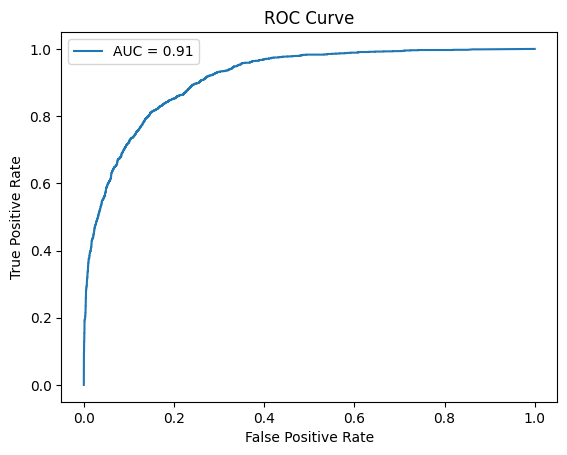

In [67]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
if len(label_encoders['Income'].classes_) == 2:
    y_prob = rf_model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()


In [68]:
y_probs = rf_model.predict_proba(X_test)[:,1]  # Probability for >50K
new_preds = (y_probs > 0.4).astype(int)  # Lower threshold to favor >50K

# Evaluate new_preds
print(classification_report(y_test, new_preds))


              precision    recall  f1-score   support

           0       0.93      0.84      0.88      4503
           1       0.63      0.82      0.71      1530

    accuracy                           0.83      6033
   macro avg       0.78      0.83      0.80      6033
weighted avg       0.86      0.83      0.84      6033



In [69]:
def predict_income_raw(features: dict, model):
    input_df = pd.DataFrame([features])
    prediction = model.predict(input_df)[0]
    return prediction


In [74]:
sample = {
    'Age': 40,
    'Workclass': 2,
    'Final Weight': 154374,
    'Education': 11,
    'EducationNum': 9,
    'Marital Status': 2,
    'Occupation': 6,
    'Relationship': 0,
    'Race': 4,
    'Gender': 1,
    'Capital Gain': 0,
    'capital loss': 0,
    'Hours per Week': 40,
    'Native Country': 38

}
pred = predict_income_raw(sample, rf_model)
print("Predicted Income:", pred)


Predicted Income: 1


In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression R²:", r2_score(y_test, y_pred_lr))


Linear Regression R²: 0.2742401786841936


In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error



rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest R²:", r2_score(y_test, y_pred_rf))
mse = mean_squared_error(y_test, y_pred_rf)
print(f'Mean Squared Error: {mse}')

Random Forest R²: 0.45054225636068335
Mean Squared Error: 0.10400663020056357


In [48]:
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

print("SVR R²:", r2_score(y_test, y_pred_svr))


SVR R²: 0.033033590832532767
